In [1]:
# =====================================================================
# Computer Vision - Feature Matching & Object Detection using SIFT
# =====================================================================
# Importing core libraries for numerical operations and computer vision
import numpy as np
import cv2 
import matplotlib.pyplot as plt

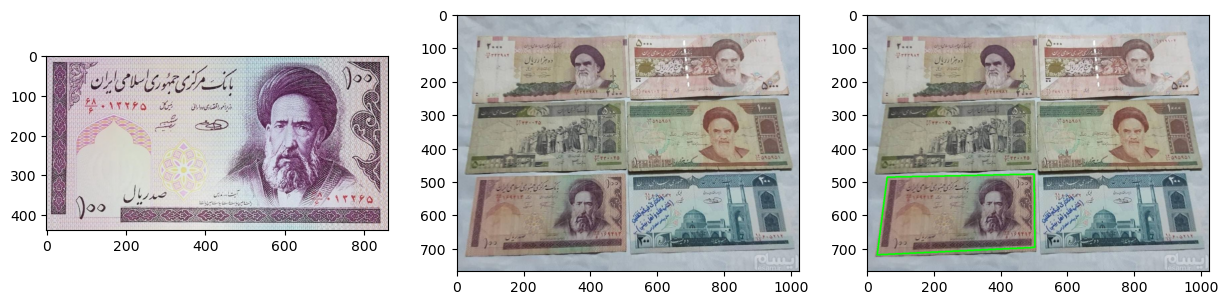

In [6]:
# =====================================================================
# Object Detection & Feature Matching using SIFT and Homography
# =====================================================================

# Load the query image (the object we want to find) and the scene image
img = cv2.imread('f3.jpg')
img0 = cv2.imread('f4.jpg')

# Convert both images to grayscale as SIFT operates on single-channel luminance
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)

# Create a copy of the scene image to draw the final detection bounding box on
res = img0.copy()

# Initialize the SIFT (Scale-Invariant Feature Transform) detector object
sift = cv2.SIFT_create()

# Detect keypoints and compute feature descriptors for both images
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Initialize the FLANN (Fast Library for Approximate Nearest Neighbors) Matcher
flan = cv2.FlannBasedMatcher()

# Find the top 2 nearest neighbors (k=2) for each descriptor to enable ratio testing
mact = flan.knnMatch(des1, des2, k=2)

# Filter matches using Lowe's Ratio Test to eliminate false positives/ambiguous matches
good = []
for m, n in mact:
    # Keep the match only if the closest distance is significantly smaller than the second closest
    if m.distance < 0.7 * n.distance:
        good.append(m)

# Check if we have enough reliable matches to calculate a valid perspective transformation
if len(good) > 10:
    # Extract the (x, y) coordinates of the matched keypoints from the query image
    scr = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    
    # Extract the (x, y) coordinates of the matched keypoints from the scene image
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
    # Compute the Homography transformation matrix (M) using RANSAC to robustly reject outlier matches
    M, mask = cv2.findHomography(scr, dst, cv2.RANSAC, 5.0)
    
    # Get the dimensions (height and width) of the original query image
    h, w = img1.shape
    
    # Define the 4 outer corner coordinates of the original query image
    pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
    
    # Transform/project the 4 corner points into the scene coordinate system using the Homography matrix
    dst = cv2.perspectiveTransform(pts, M)
    
    # Draw a green bounding box around the transformed corner points in the scene image (thickness=3)
    res = cv2.polylines(res, [np.int32(dst)], True, (0, 255, 0), 3)
else:
    # Triggered if the number of reliable matches is below the safety threshold
    print('nist')

# Setup a wide canvas to plot the visual results side-by-side
plt.figure(figsize=[15, 4])   

# Plot 1: Display the original query object (converting BGR back to RGB for matplotlib)
plt.subplot(131); plt.imshow(img[..., ::-1])

# Plot 2: Display the original target scene where the object is hidden
plt.subplot(132); plt.imshow(img0[..., ::-1])

# Plot 3: Display the final result showing the automatically localized object
plt.subplot(133); plt.imshow(res[..., ::-1])

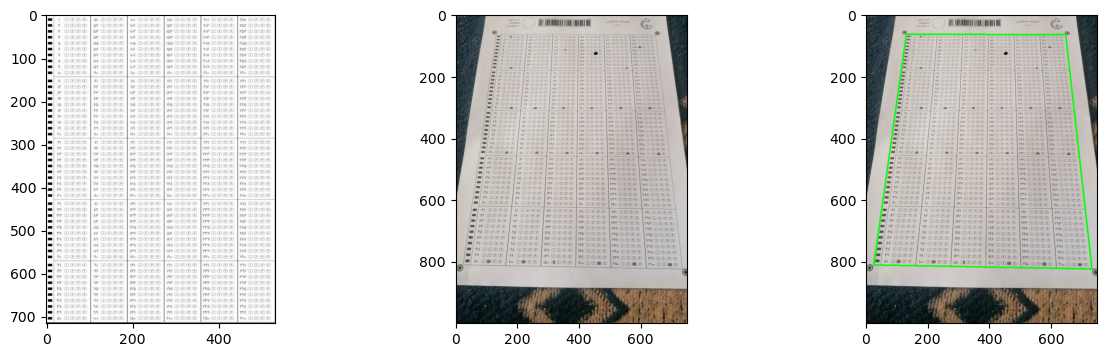

In [7]:
# =====================================================================
# Scale-Invariant Feature Matching and Target Localization via SIFT
# =====================================================================

# Load the target/query object image and the main scene image from storage
img = cv2.imread('tes1.jpg')
img0 = cv2.imread('tes2.jpg')

# Convert both input images from BGR to Grayscale for intensity-based SIFT analysis
img1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img2 = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)

# Duplicate the scene image to use as a canvas for drawing the detected bounding box
res = img0.copy()

# Initialize the OpenCV Scale-Invariant Feature Transform (SIFT) detector instance
sift = cv2.SIFT_create()

# Detect keypoints and compute multi-dimensional descriptors for both images
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Initialize the Fast Library for Approximate Nearest Neighbors (FLANN) Matcher
flan = cv2.FlannBasedMatcher()

# Perform a k-Nearest Neighbors search with k=2 to find the two closest features
mact = flan.knnMatch(des1, des2, k=2)

# Evaluate matches using Lowe's Ratio Test to discard indistinct background noise
good = []
for m, n in mact:
    # Retain the match only if the primary match is significantly closer than the secondary match
    if m.distance < 0.7 * n.distance:
        good.append(m)

# Execute geometric object localization if the number of robust matches exceeds the threshold (10)
if len(good) > 10:
    # Compile the (x, y) coordinates of the filtered keypoints from the query/object image
    scr = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    
    # Compile the matching (x, y) coordinates of the keypoints from the scene image
    dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    
    # Calculate the perspective Homography matrix (M) using RANSAC for outlier exclusion
    M, mask = cv2.findHomography(scr, dst, cv2.RANSAC, 5.0)
    
    # Extract the image dimensions (height and width) of the template object
    h, w = img1.shape
    
    # Define the four boundary corners of the original query image layout
    pts = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
    
    # Project the template corners into the scene perspective domain using the Homography matrix
    dst = cv2.perspectiveTransform(pts, M)
    
    # Overlay a green bounding polygon outline around the localized object in the scene copy
    res = cv2.polylines(res, [np.int32(dst)], True, (0, 255, 0), 3)
else:
    # Output an alert in the console if valid feature cross-matches are insufficient
    print('nist')

# Instantiate a wide multi-panel canvas for plotting the qualitative results
plt.figure(figsize=[15, 4])    

# Subplot 1: Render the original cropped template object (converting BGR to RGB for correct coloring)
plt.subplot(131); plt.imshow(img[..., ::-1])

# Subplot 2: Render the original target scene prior to execution
plt.subplot(132); plt.imshow(img0[..., ::-1])

# Subplot 3: Render the final localized result containing the computed perspective box
plt.subplot(133); plt.imshow(res[..., ::-1])